## Chargement des packages

In [1]:

# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from pandas_profiling import ProfileReport


c:\Users\nmako\anaconda3\envs\ml_projet\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\nmako\AppData\Local\Temp\ipykernel_15260\884969296.py:8: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  from pandas_profiling import ProfileReport


## Base des données


 les données sont disponibles sur Kaggle  https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset?resource=download


 ### objectif de l'analyse

L'objectif de cette analyse est de construire un modèle de classification pour prédire si une personne est eligible pour un prêt en fonction de ses caractéristiques. Cette base de données sera divisée en ensembles d'apprentissage et de test pour entraîner et évaluer les performances du modèle.  

### Contenu de la base de données

La base de données contient les colonnes suivantes :
 - `Loan_ID` : identifiant du prêt
 - `Gender` : sexe de l'emprunteur
- `Married` : statut marital de l'emprunteur
- `Dependents` : nombre de personnes à charge
 - `Education` : niveau d'éducation de l'emprunteur
 - `Self_Employed` : statut d'emploi indépendant de l'emprunteur
 - `ApplicantIncome` : revenu de l'emprunteur
 - `CoapplicantIncome` : revenu du co-emprunteur
 - `LoanAmount` : montant du prêt demandé
 - `Loan_Amount_Term` : durée du prêt en mois
 - `Credit_History` : historique de crédit de l'emprunteur (0 = mauvais, 1 = bon)
 - `Property_Area` : zone géographique de la propriété 
 - `Loan_Status` : statut du prêt (Y = approuvé, N = non approuvé)

 ### Objectif de l'analyse
 L'objectif de cette analyse est de construire un modèle de classification pour prédire si une personne est éligible pour un prêt en fonction de ses caractéristiques. Cette base de données sera divisée en ensembles d'apprentissage et de test pour entraîner et évaluer les performances du modèle.    


## Importation et nettoyage des données

In [2]:
data_path = Path(r"C:\Users\nmako\OneDrive\Documents\Data-Science-Projects-Repository\Machine Learning TP\Application-ML-Detection-Defauts-Paiements-Credits-Bancaires\data\raw\train_credit.csv")
data = pd.read_csv(data_path)
df = data.copy()
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
## les types de données
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [4]:
#valeurs manquantes
df.isnull().sum().sort_values(ascending=False)

Credit_History       50
Self_Employed        32
LoanAmount           22
Dependents           15
Loan_Amount_Term     14
Gender               13
Married               3
Loan_ID               0
Education             0
ApplicantIncome       0
CoapplicantIncome     0
Property_Area         0
Loan_Status           0
dtype: int64

In [5]:
# remplacement des valeurs manquantes

cat_data = df.select_dtypes(include=['object']).columns
num_data = df.select_dtypes(exclude=['object']).columns

cat_data = df[cat_data].apply(lambda x: x.fillna(x.mode()[0])) # remplacement des valeurs manquantes dans les colonnes catégorielles par la valeur la plus fréquente
num_data = df[num_data].fillna(method = 'bfill') # remplacement des valeurs manquantes dans les colonnes numériques par la valeur précédente
cat_data = cat_data.drop(['Loan_Status','Loan_ID'], axis=1)

In [6]:
# remplacer les valeurs catégorielles par des valeurs numériques avec label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder() 
for col in cat_data.columns:
    cat_data[col] = le.fit_transform(cat_data[col]) 
cat_data


,Gender,Married,Dependents,Education,Self_Employed,Property_Area
0,1,0,0,0,0,2
1,1,1,1,0,0,0
2,1,1,0,0,1,2
3,1,1,0,1,0,2
4,1,0,0,0,0,2
...,...,...,...,...,...,...
609,0,0,0,0,0,0
610,1,1,3,0,0,0
611,1,1,1,0,0,2
612,1,1,2,0,0,2


In [7]:
# concatenation des donnees catégorielles et numériques pour former les features
features = pd.concat([cat_data, num_data], axis=1)
target = df['Loan_Status'].apply(lambda x: 1 if x == 'Y' else 0) # conversion de la variable cible en binaire
features

,Gender,Married,Dependents,Education,Self_Employed,Property_Area,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,1,0,0,0,0,2,5849,0.0,128.0,360.0,1.0
1,1,1,1,0,0,0,4583,1508.0,128.0,360.0,1.0
2,1,1,0,0,1,2,3000,0.0,66.0,360.0,1.0
3,1,1,0,1,0,2,2583,2358.0,120.0,360.0,1.0
4,1,0,0,0,0,2,6000,0.0,141.0,360.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,0,2900,0.0,71.0,360.0,1.0
610,1,1,3,0,0,0,4106,0.0,40.0,180.0,1.0
611,1,1,1,0,0,2,8072,240.0,253.0,360.0,1.0
612,1,1,2,0,0,2,7583,0.0,187.0,360.0,1.0


In [8]:
target

0      1
1      0
2      1
3      1
4      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: Loan_Status, Length: 614, dtype: int64

## Analyse exploratoire des données

l analyse exploratoire des données consiste à explorer les données pour en extraire des informations utiles, identifier des tendances, des relations entre les variables,
et des anomalies, et de mieux comprendre les données avant de les utiliser pour l'apprentissage automatique.

Tools : Sweetviz and pandas-profiling

In [9]:
df = pd.concat([features, target], axis=1)
df

,Gender,Married,Dependents,Education,Self_Employed,Property_Area,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
0,1,0,0,0,0,2,5849,0.0,128.0,360.0,1.0,1
1,1,1,1,0,0,0,4583,1508.0,128.0,360.0,1.0,0
2,1,1,0,0,1,2,3000,0.0,66.0,360.0,1.0,1
3,1,1,0,1,0,2,2583,2358.0,120.0,360.0,1.0,1
4,1,0,0,0,0,2,6000,0.0,141.0,360.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,0,2900,0.0,71.0,360.0,1.0,1
610,1,1,3,0,0,0,4106,0.0,40.0,180.0,1.0,1
611,1,1,1,0,0,2,8072,240.0,253.0,360.0,1.0,1
612,1,1,2,0,0,2,7583,0.0,187.0,360.0,1.0,1


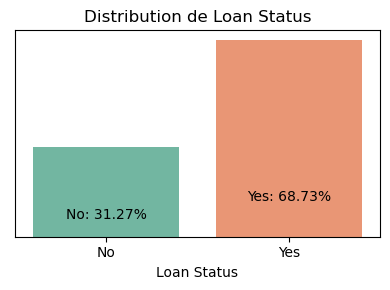

In [10]:
# analyse de la varible cible

plt.figure(figsize=(4, 3))
sns.countplot(x=target, palette='Set2')
plt.title('Distribution de Loan Status')
plt.xlabel('Loan Status')
yes = target.value_counts()[1] / len(target) * 100
no = target.value_counts()[0] / len(target) * 100
plt.text(1, yes + 1, f'Yes: {yes:.2f}%', ha='center', va='bottom')
plt.text(0, no + 1, f'No: {no:.2f}%', ha='center', va='bottom')
plt.xticks([1, 0], ['Yes', 'No'])
#remove the y-axis label
plt.ylabel('')
# remove the y-axis ticks
plt.yticks([])
plt.tight_layout()
plt.show()

c:\Users\nmako\anaconda3\envs\ml_projet\lib\site-packages\seaborn\axisgrid.py:712: UserWarning: Using the countplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


<Figure size 800x600 with 0 Axes>

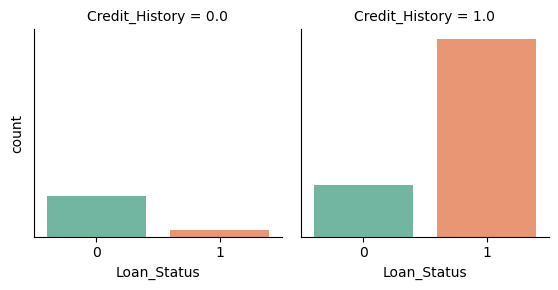

In [11]:
# analyse de la relation entre variable historique de crédit et statut de prêt
plt.figure(figsize=(8, 6))
grid = sns.FacetGrid(df, col='Credit_History', height=3, aspect=1)
grid.map(sns.countplot, 'Loan_Status', palette='Set2')
plt.yticks([]) 
plt.show()

c:\Users\nmako\anaconda3\envs\ml_projet\lib\site-packages\seaborn\axisgrid.py:712: UserWarning: Using the countplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


<Figure size 800x600 with 0 Axes>

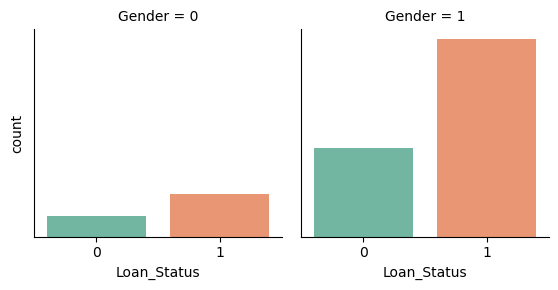

In [ ]:
# analyse de la relation entre variable cible et le gender
plt.figure(figsize=(8, 6))
grid = sns.FacetGrid(df, col='Gender', height=3, aspect=1)
grid.map(sns.countplot, 'Loan_Status', palette='Set2')
plt.yticks([]) 
plt.show()

c:\Users\nmako\anaconda3\envs\ml_projet\lib\site-packages\seaborn\axisgrid.py:712: UserWarning: Using the countplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


<Figure size 800x600 with 0 Axes>

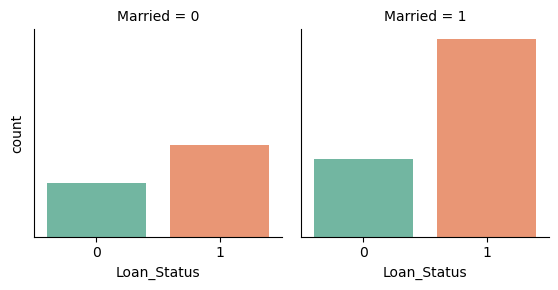

In [15]:
# analyse de la relation entre variable cible et le gender
plt.figure(figsize=(8, 6))
grid = sns.FacetGrid(df, col='Married', height=3, aspect=1)
grid.map(sns.countplot, 'Loan_Status', palette='Set2')
plt.yticks([]) 
plt.show()